In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Resume.csv")

In [3]:
print(df.shape)      # rows and columns

(2484, 4)


In [4]:
print(df.head()) 

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  


In [5]:
print(df.columns)    # column names

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')


In [6]:
df

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR
...,...,...,...,...
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


## Data Dictionary

| Column | What it means | Example |
|--------|--------------|---------|
| ID | Unique ID number for each resume | 16852973 |
| Resume_str | Full plain text of the resume | "HR ADMINISTRATOR/MARKETING ASSOCIATE..." |
| Resume_html | Same resume in HTML format (with styling tags) | `<div class="fontsize...` |
| Category | Job category the resume belongs to | HR, AVIATION, Data Science |

## Dataset Summary
- Total resumes: 2484
- Total columns: 4
- Job categories include: HR, AVIATION and more

In [7]:
print("Total Resumes:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nJob Categories:")
print(df['Category'].value_counts())

Total Resumes: 2484
Total Columns: 4

Job Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

In [16]:
import re

def clean_resume(text):
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^\w\s]', '', text)          # remove punctuation
    text = re.sub(r'\s+', ' ', text)             # remove extra whitespace
    text = text.lower().strip()
    return text

df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)
df[['Resume_str', 'cleaned_resume']].head(3)

,Resume_str,cleaned_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over 20 years experience i...


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns     

In [19]:
df['resume_length'] = df['Resume_str'].apply(len)
print(df['resume_length'].describe())

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: resume_length, dtype: float64


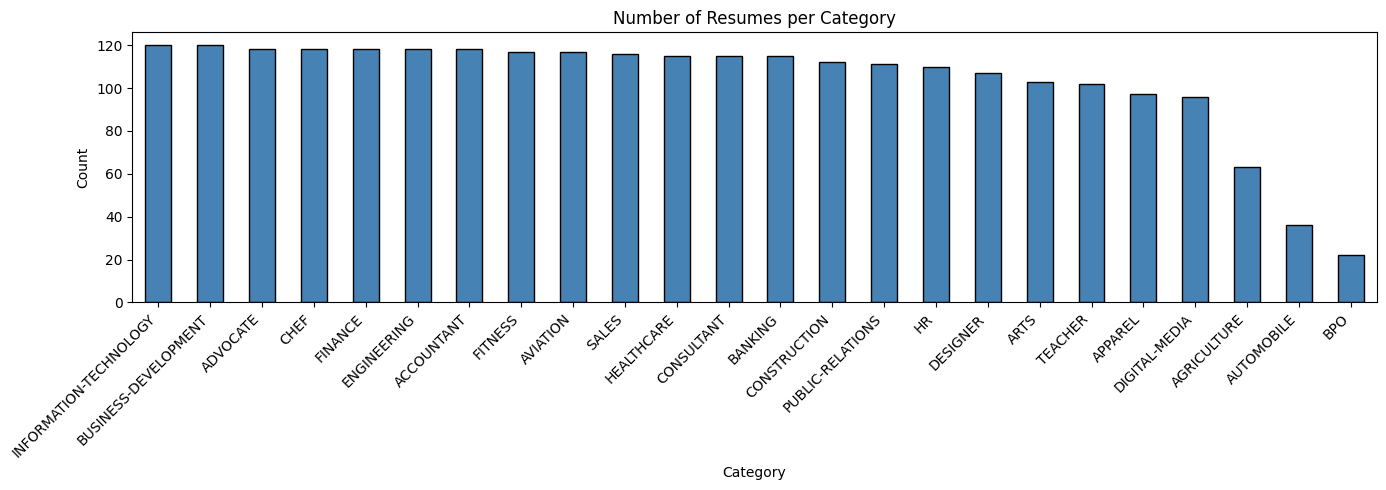

In [20]:
plt.figure(figsize=(14, 5))
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Resumes per Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150)
plt.show()

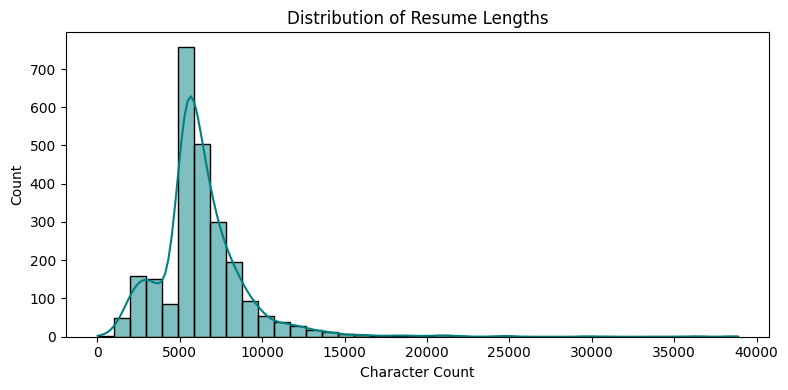

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(df['resume_length'], bins=40, kde=True, color='teal')
plt.title('Distribution of Resume Lengths')
plt.xlabel('Character Count')
plt.tight_layout()
plt.savefig('resume_length_dist.png', dpi=150)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_26016\636533226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='resume_length', palette='Set2')


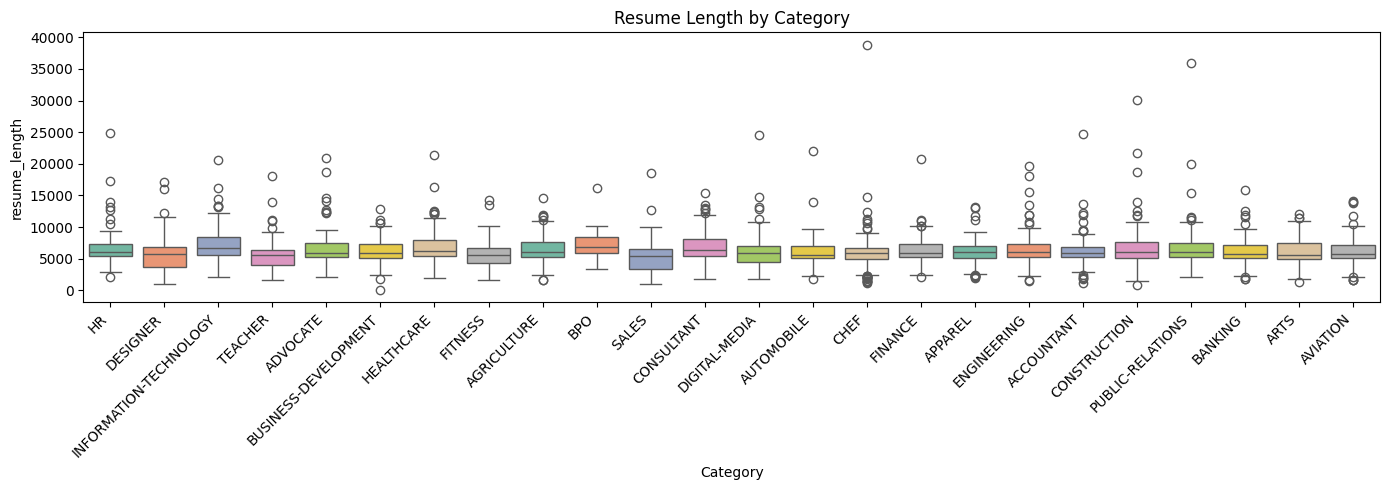

In [22]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='Category', y='resume_length', palette='Set2')
plt.title('Resume Length by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('length_by_category.png', dpi=150)
plt.show()

In [23]:
avg_len = df.groupby('Category')['resume_length'].mean().sort_values(ascending=False)
print(avg_len)

Category
BPO                       7317.681818
INFORMATION-TECHNOLOGY    7227.550000
HEALTHCARE                6996.182609
PUBLIC-RELATIONS          6913.432432
CONSULTANT                6844.347826
HR                        6760.763636
CONSTRUCTION              6618.455357
AGRICULTURE               6605.285714
ADVOCATE                  6575.161017
ENGINEERING               6476.033898
AUTOMOBILE                6321.250000
FINANCE                   6316.161017
ACCOUNTANT                6293.508475
BANKING                   6191.191304
AVIATION                  6189.205128
DIGITAL-MEDIA             6094.729167
BUSINESS-DEVELOPMENT      6043.975000
APPAREL                   6030.123711
ARTS                      6000.368932
CHEF                      5995.542373
DESIGNER                  5647.233645
FITNESS                   5586.803419
TEACHER                   5562.803922
SALES                     5270.034483
Name: resume_length, dtype: float64
